# Valutazione dei modelli ML

Riepilogo riproducibile dell'ultimo run completato. Il notebook legge gli export di valutazione e le figure salvate: non riaddestra i modelli e non ricalcola le metriche.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

root = Path.cwd().resolve()
for candidate in (root, *root.parents):
    if (candidate/"artifacts/runs/latest_run.txt").is_file():
        root = candidate
        break
else:
    raise FileNotFoundError("Impossibile trovare artifacts/runs/latest_run.txt dal working directory")

latest_run_file = root/"artifacts/runs/latest_run.txt"
run_dir = Path(latest_run_file.read_text(encoding="utf-8").strip())
if not run_dir.is_absolute():
    run_dir = root/run_dir
if not run_dir.is_dir():
    raise FileNotFoundError(f"Run indicato ma non trovato: {run_dir}")

metadata = json.loads((run_dir/"metadata.json").read_text(encoding="utf-8"))
tables_dir = run_dir/"evaluation"/"tables"
figures_dir = run_dir/"evaluation"/"figures"
run_card = pd.DataFrame(
    {
        "Campo": ["Run", "Stato", "Soggetti", "Gruppi", "CV esterna", "Metrica inner"],
        "Valore": [
            metadata.get("run_id"),
            metadata.get("status"),
            metadata.get("subjects", {}).get("n_subjects"),
            metadata.get("subjects", {}).get("group_counts"),
            f"{metadata.get('validation_config', {}).get('outer_n_repeats')} ripetizioni × {metadata.get('validation_config', {}).get('outer_n_splits')} fold",
            metadata.get("validation_config", {}).get("primary_metric"),
        ],
    }
)
display(run_card)
print(f"Prevalenza MS: {metadata.get('subjects', {}).get('group_counts', {}).get('ms', 0) / metadata.get('subjects', {}).get('n_subjects', 1):.1%}")

,Campo,Valore
0,Run,run_20260924T124737_646339Z
1,Stato,completed
2,Soggetti,32
3,Gruppi,"{'ms': 24, 'hc': 8}"
4,CV esterna,5 ripetizioni × 4 fold
5,Metrica inner,roc_auc


Prevalenza MS: 75.0%


## Risultati

Le medie e deviazioni standard dei fold descrivono la variabilità nella nested cross-validation ripetuta. 
I fold ripetuti non sono osservazioni indipendenti e gli intervalli dei singoli modelli non costituiscono un test appaiato tra modelli. La classe positiva è MS.

In [ ]:
fold_summary = pd.read_csv(tables_dir/"fold_metric_summary.csv")
oof_metrics = pd.read_csv(tables_dir/"aggregated_oof_metrics.csv")
bootstrap_ci = pd.read_csv(tables_dir/"bootstrap_confidence_intervals.csv")
subject_errors = pd.read_csv(tables_dir/"subject_error_analysis.csv")
feature_stability = pd.read_csv(tables_dir/"feature_stability.csv")

fold_columns = [
    "model",
    "roc_auc_mean", "roc_auc_std",
    "average_precision_mean",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "sensitivity_mean", "specificity_mean",
]
fold_view = fold_summary[fold_columns].copy()
pooled_view = oof_metrics[["model", "roc_auc", "average_precision", "balanced_accuracy", "sensitivity", "specificity", "brier_score"]].copy()
comparison = fold_view.merge(pooled_view, on="model", suffixes=("_fold", "_oof"))

ci_wide = bootstrap_ci.pivot(index="model", columns="metric", values=["ci_lower", "ci_upper"])
ci_wide.columns = [f"{metric}_{bound}" for bound, metric in ci_wide.columns]
comparison = comparison.merge(ci_wide.reset_index(), on="model")
comparison = comparison.sort_values("roc_auc", ascending=False)
display(comparison.round(3))

,model,roc_auc_mean,roc_auc_std,average_precision_mean,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,specificity_mean,roc_auc,average_precision,...,roc_auc_ci_lower,sensitivity_ci_lower,specificity_ci_lower,average_precision_ci_upper,balanced_accuracy_ci_upper,brier_score_ci_upper,f1_ci_upper,roc_auc_ci_upper,sensitivity_ci_upper,specificity_ci_upper
5,channel__svm,0.588,0.243,0.858,0.496,0.092,0.917,0.075,0.594,0.847,...,0.365,0.875,0.000,0.932,0.500,0.214,0.857,0.807,1.000,0.000
4,channel__random_forest,0.517,0.213,0.821,0.500,0.191,0.650,0.350,0.557,0.815,...,0.333,0.417,0.000,0.930,0.625,0.286,0.793,0.781,0.833,0.625
1,channel__knn,0.517,0.207,0.782,0.496,0.128,0.792,0.200,0.542,0.780,...,0.318,0.667,0.000,0.922,0.729,0.302,0.885,0.771,0.958,0.625
6,channel__xgboost,0.544,0.240,0.814,0.538,0.224,0.675,0.400,0.536,0.780,...,0.286,0.667,0.125,0.916,0.792,0.298,0.902,0.776,0.958,0.750
8,roi__knn,0.500,0.225,0.783,0.467,0.144,0.758,0.175,0.531,0.765,...,0.297,0.750,0.000,0.920,0.729,0.296,0.902,0.760,1.000,0.625
0,channel__dummy,0.500,0.000,0.750,0.500,0.000,1.000,0.000,0.500,0.750,...,0.500,1.000,0.000,0.750,0.500,0.188,0.857,0.500,1.000,0.000
7,roi__dummy,0.500,0.000,0.750,0.500,0.000,1.000,0.000,0.500,0.750,...,0.500,1.000,0.000,0.750,0.500,0.188,0.857,0.500,1.000,0.000
10,roi__logistic_elastic_net,0.475,0.218,0.797,0.483,0.170,0.567,0.400,0.500,0.808,...,0.286,0.375,0.125,0.900,0.667,0.312,0.791,0.703,0.750,0.750
9,roi__lda,0.521,0.262,0.825,0.462,0.147,0.675,0.250,0.495,0.770,...,0.260,0.625,0.000,0.902,0.708,0.373,0.868,0.734,0.958,0.625
13,roi__xgboost,0.523,0.216,0.806,0.508,0.211,0.667,0.350,0.495,0.764,...,0.292,0.542,0.000,0.909,0.667,0.316,0.833,0.708,0.875,0.625


## Confronto delle metriche pooled

I grafici mostrano stima pooled e IC bootstrap al 95%. Il riferimento `0.5` è il livello non informativo per ROC-AUC e balanced accuracy; non rappresenta la baseline di average precision, che dipende dalla prevalenza MS. Il modello dummy resta visibile nei riepiloghi ma non nel ranking dei classificatori.

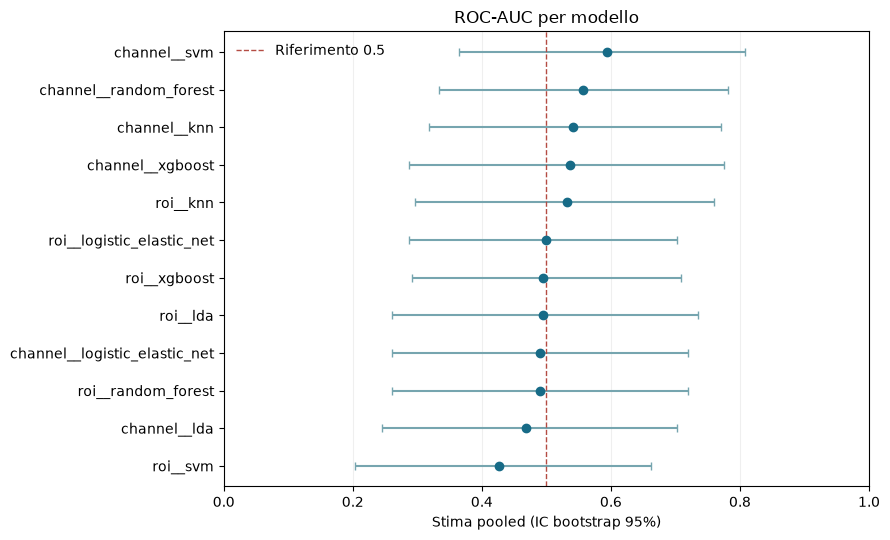

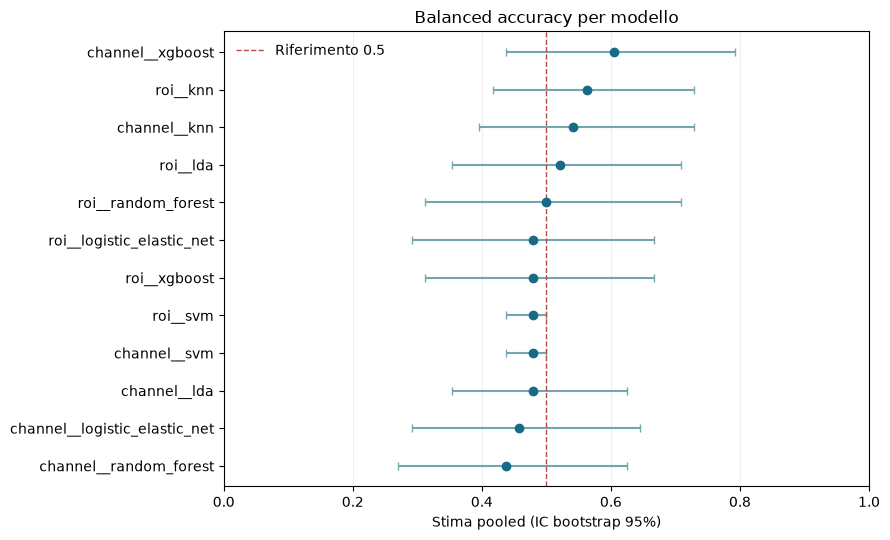

In [3]:
def plot_pooled_metric(metric, title):
    plot_data = bootstrap_ci.loc[
        bootstrap_ci["metric"].eq(metric)
        & ~bootstrap_ci["model"].str.endswith("__dummy")
    ].sort_values("estimate")
    positions = range(len(plot_data))
    lower_error = plot_data["estimate"] - plot_data["ci_lower"]
    upper_error = plot_data["ci_upper"] - plot_data["estimate"]

    figure, axis = plt.subplots(figsize=(9, 5.5))
    axis.errorbar(
        plot_data["estimate"],
        positions,
        xerr=[lower_error, upper_error],
        fmt="o",
        color="#176B87",
        ecolor="#76A5AF",
        capsize=3,
    )
    axis.axvline(0.5, color="#B44C43", linestyle="--", linewidth=1, label="Riferimento 0.5")
    axis.set_yticks(list(positions), plot_data["model"])
    axis.set_xlim(0, 1)
    axis.set_xlabel("Stima pooled (IC bootstrap 95%)")
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.2)
    axis.legend(frameon=False)
    figure.tight_layout()
    plt.show()

plot_pooled_metric("roc_auc", "ROC-AUC per modello")
plot_pooled_metric("balanced_accuracy", "Balanced accuracy per modello")

## Figure del run

Queste figure sono gli export originali prodotti dalla pipeline di valutazione. Se una figura non è presente nel run, la cella la segnala e continua.

oof_roc_curves.png


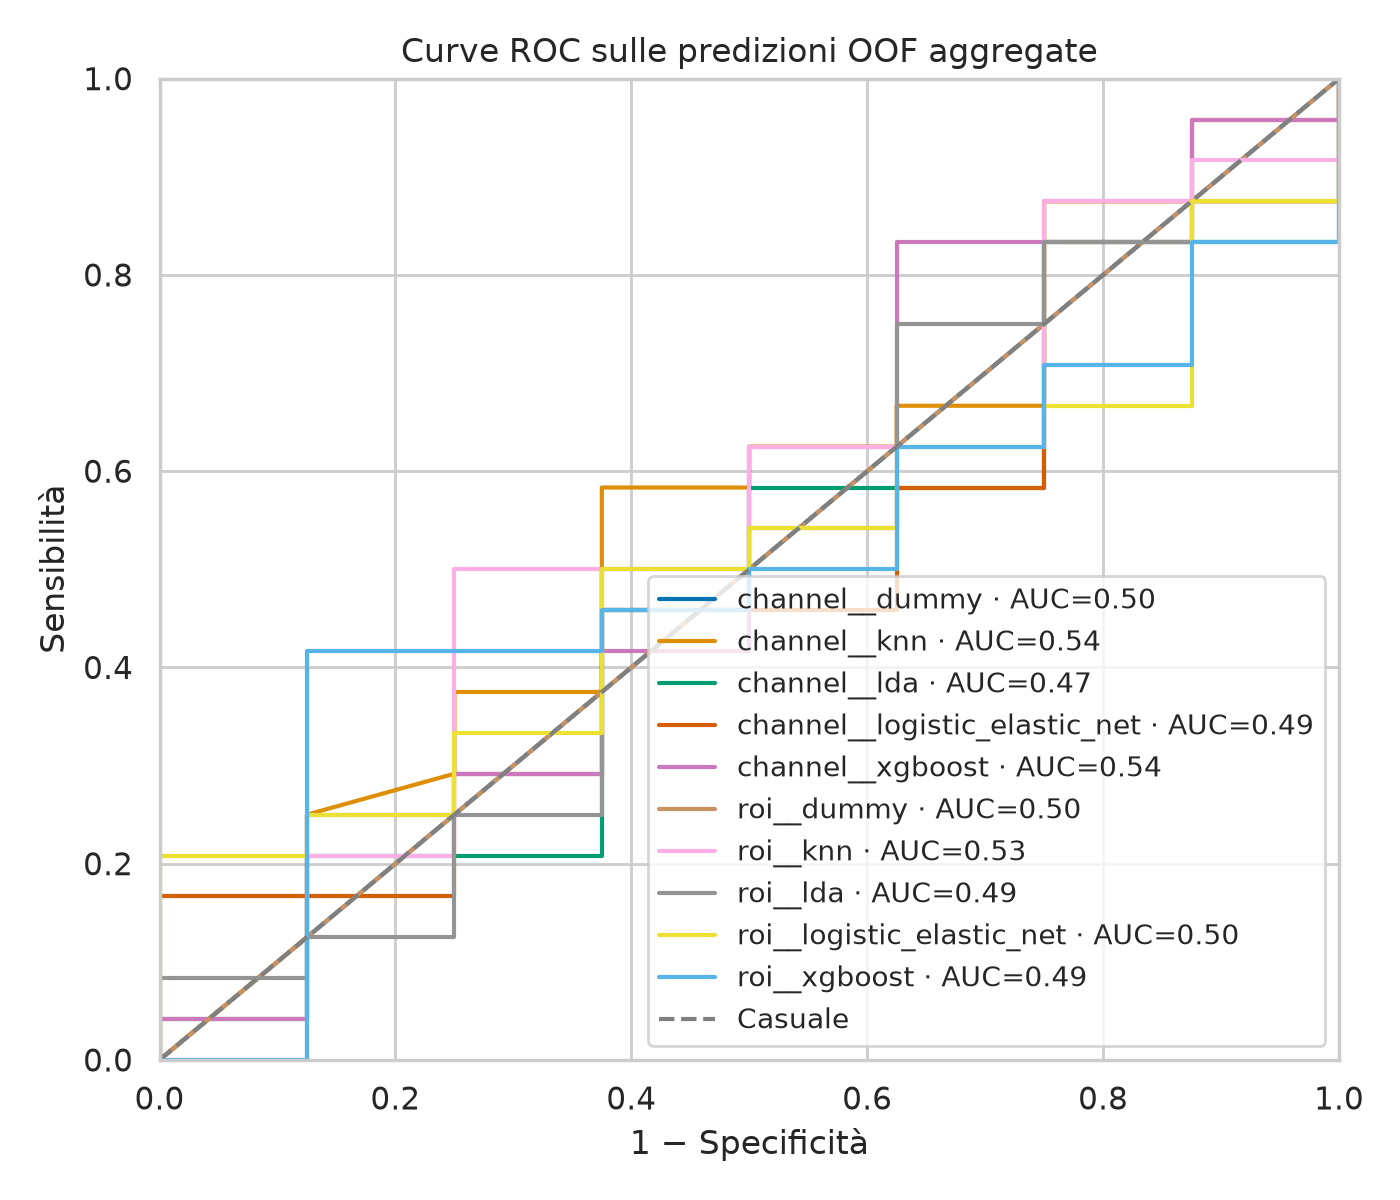

oof_precision_recall_curves.png


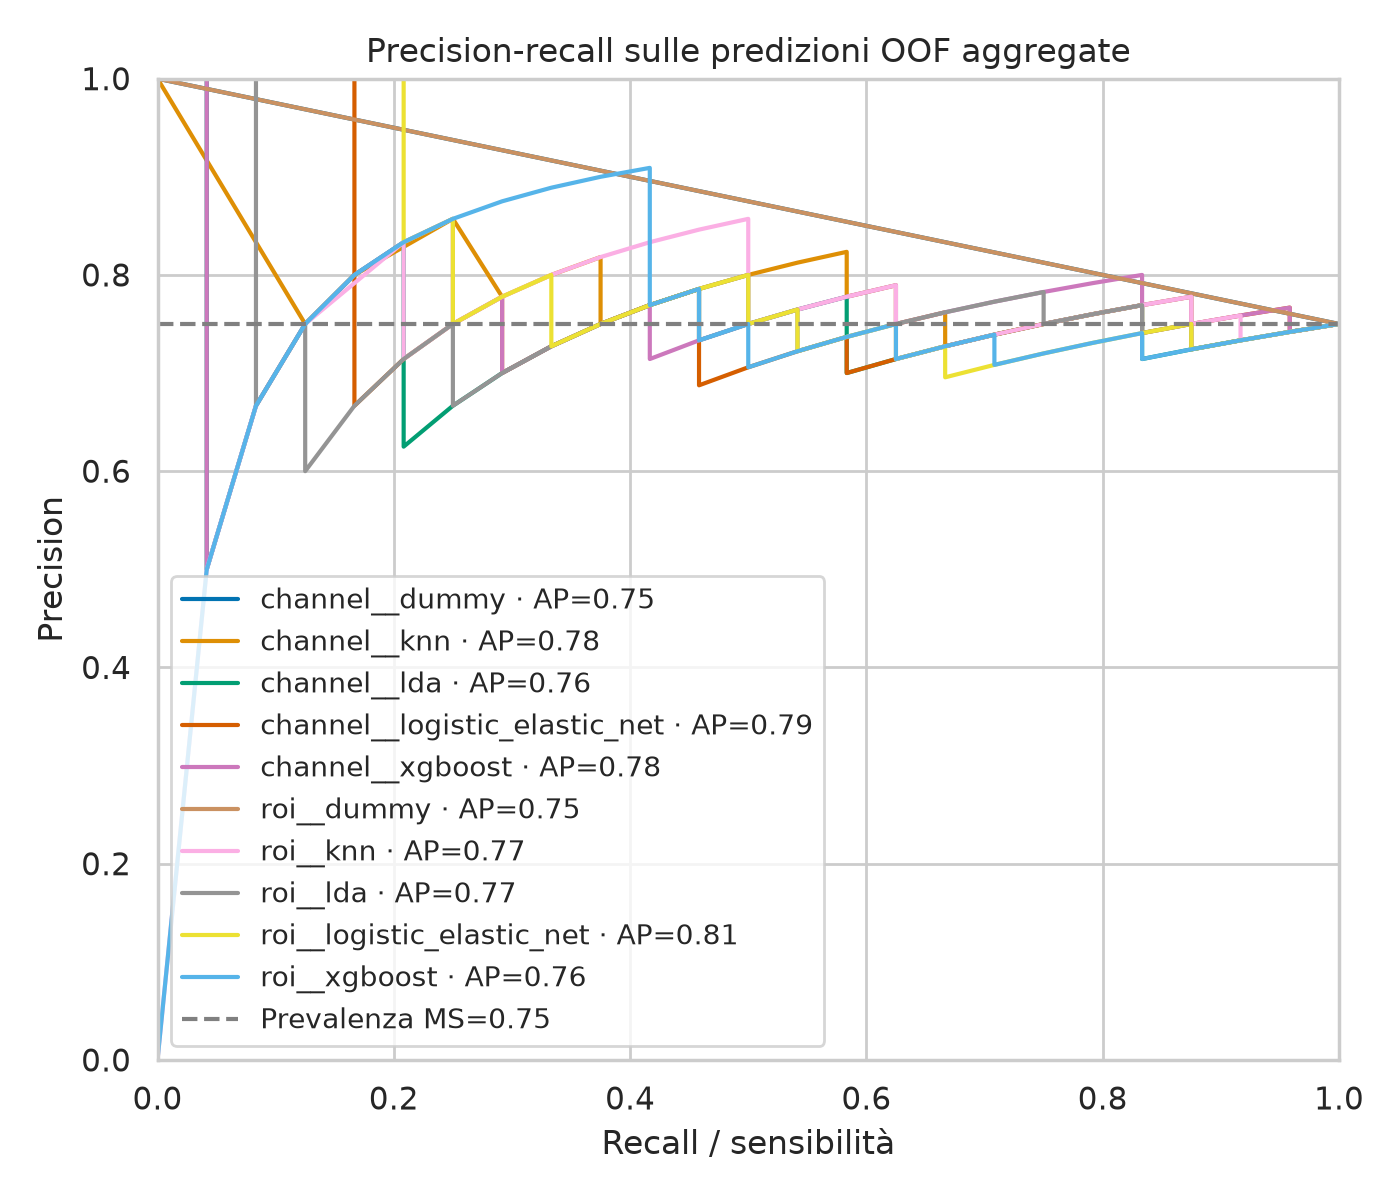

confusion_matrices.png


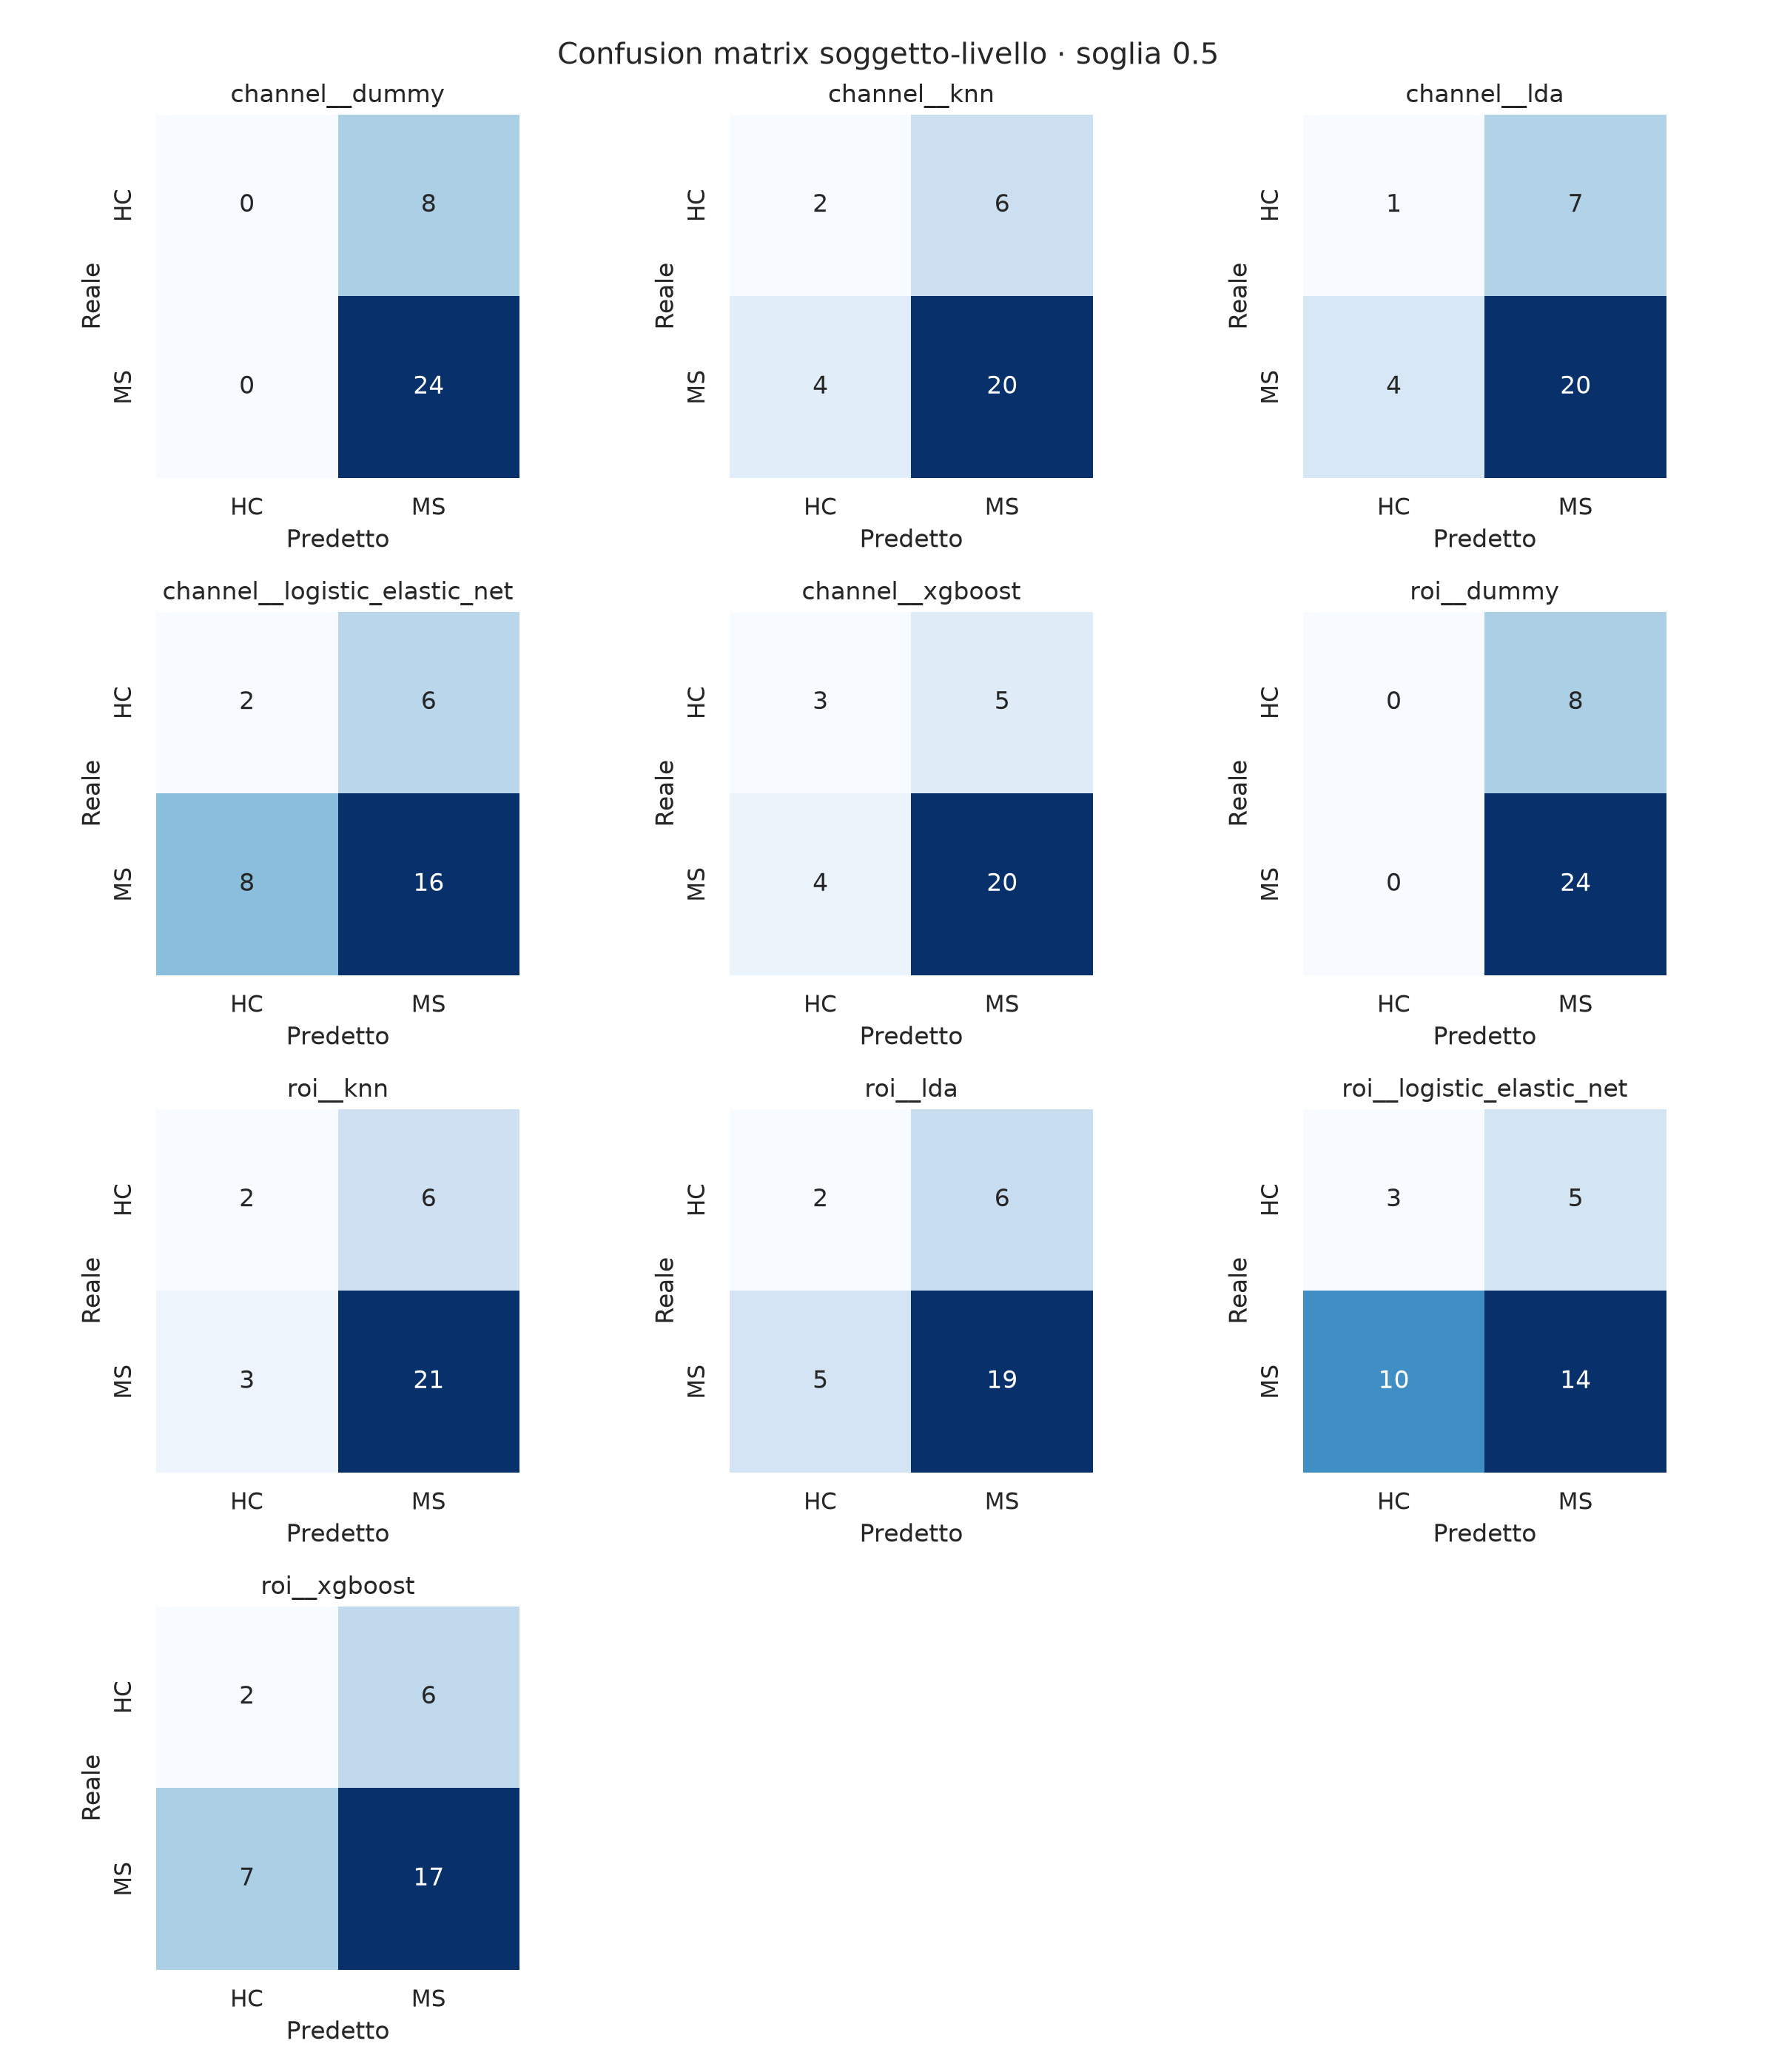

fold_metric_distributions.png


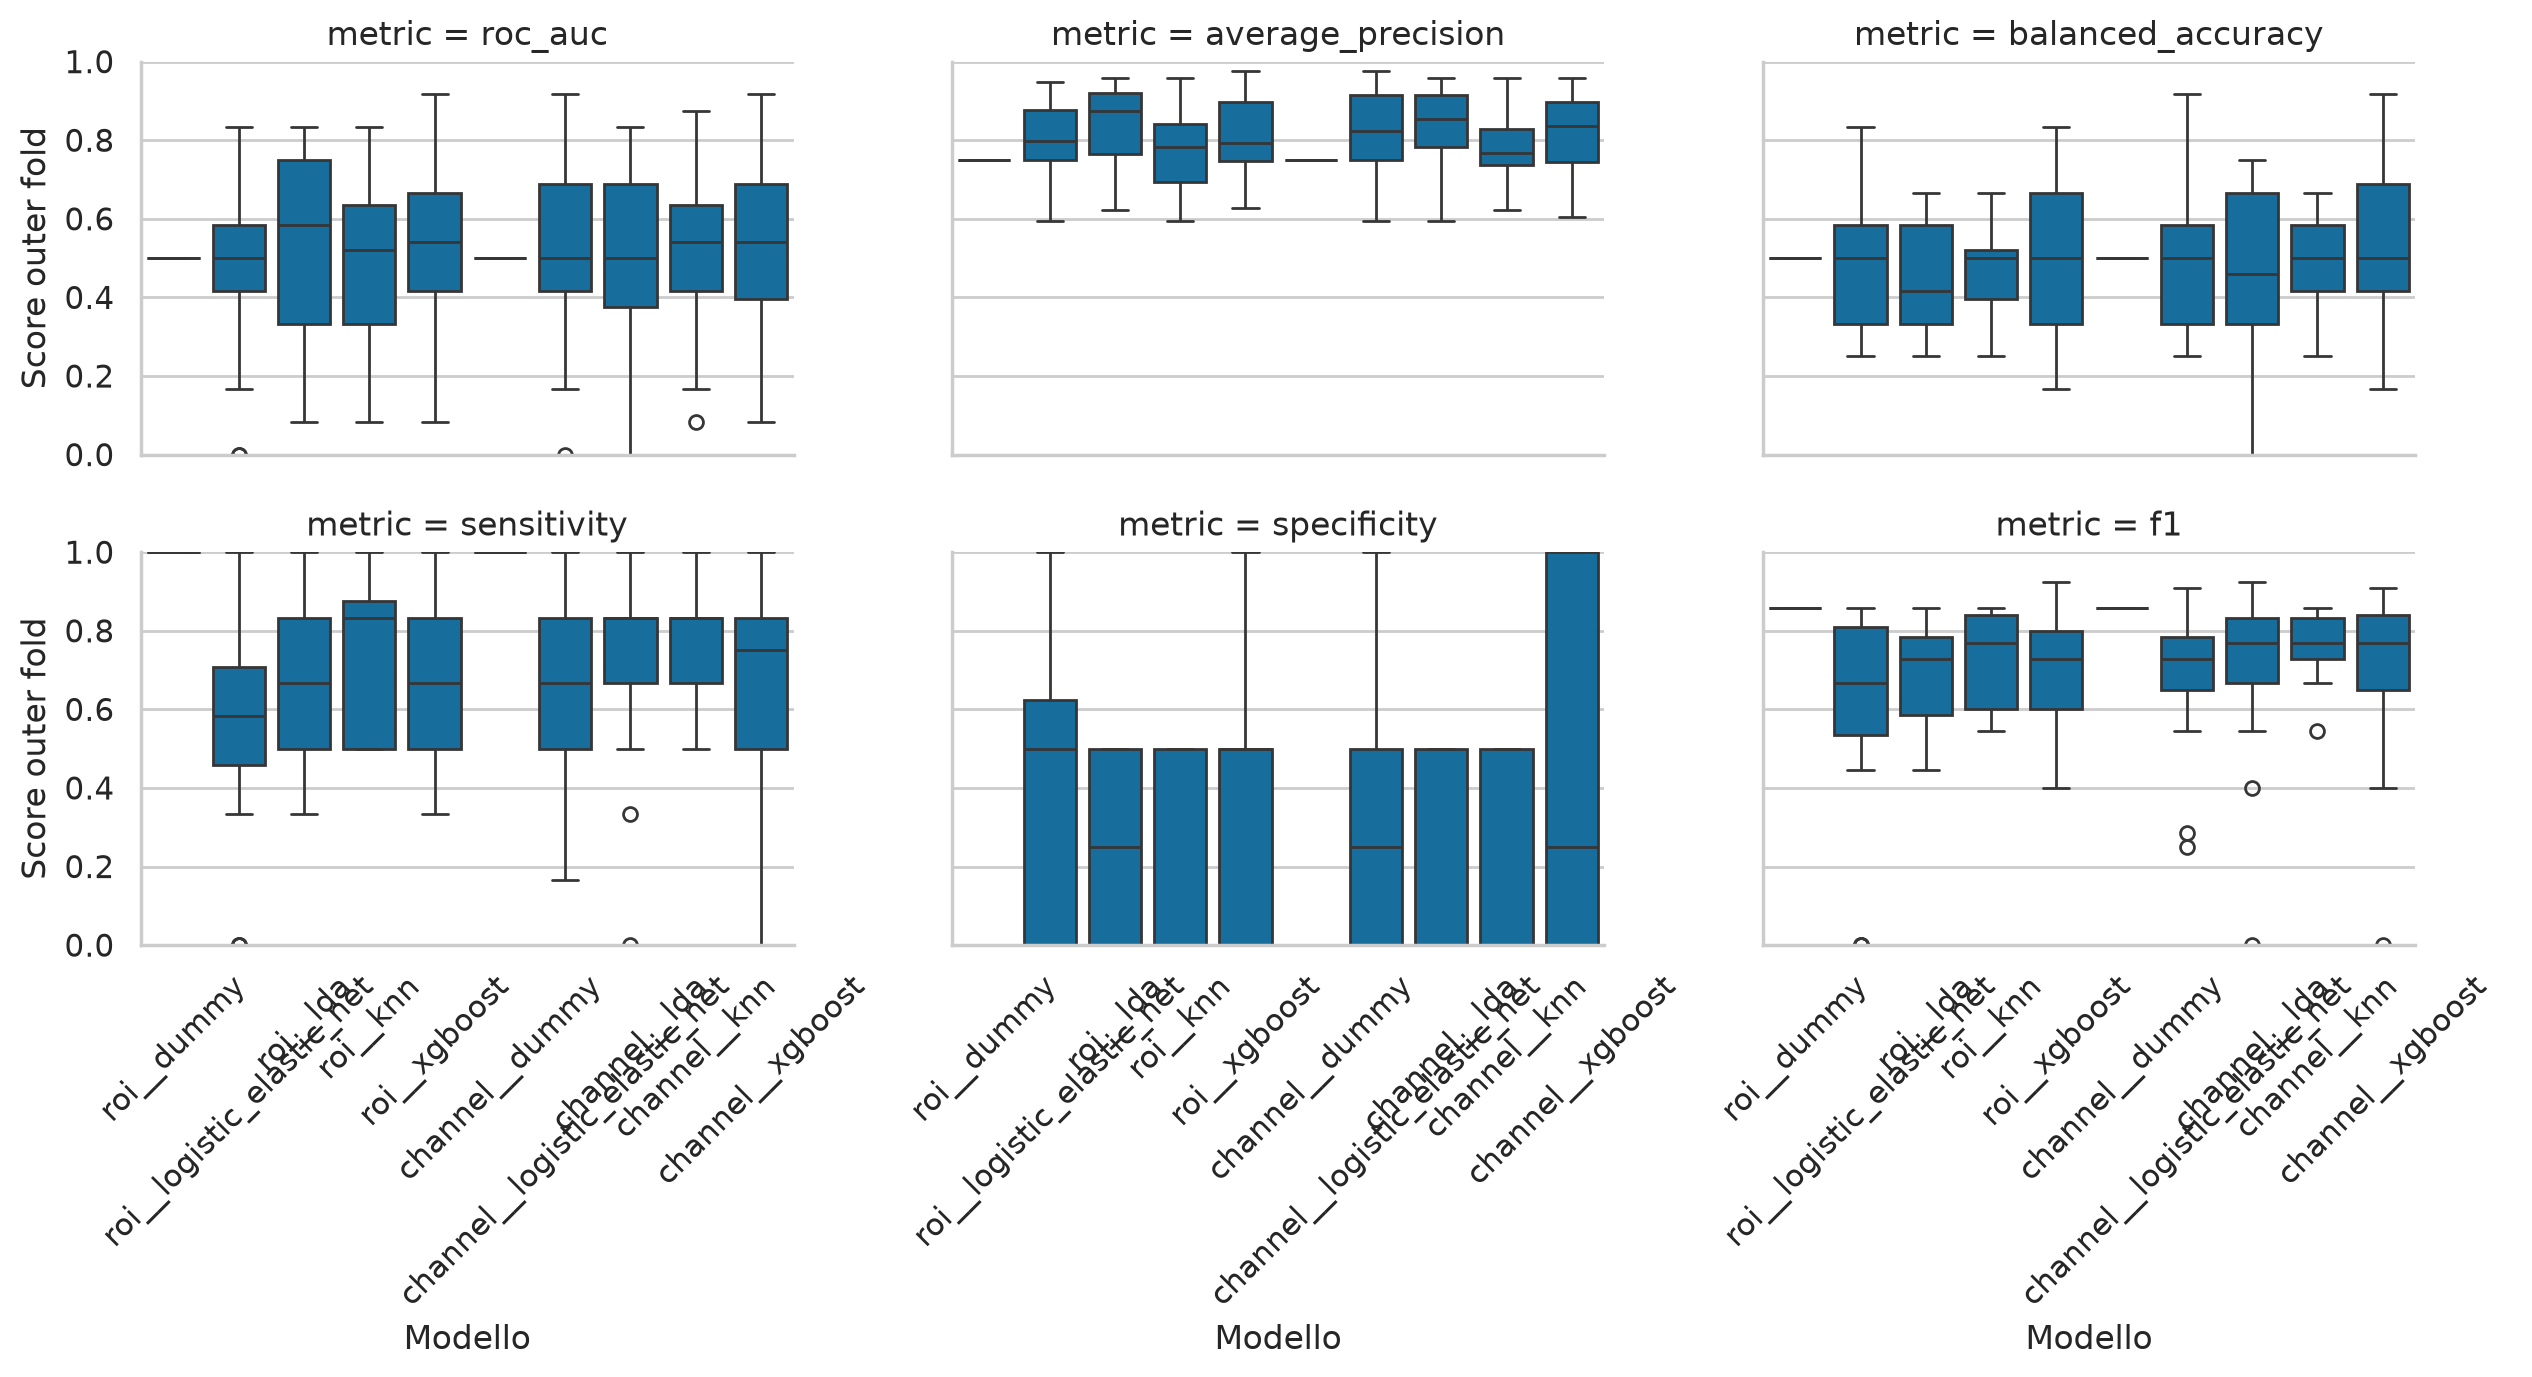

bootstrap_balanced_accuracy.png


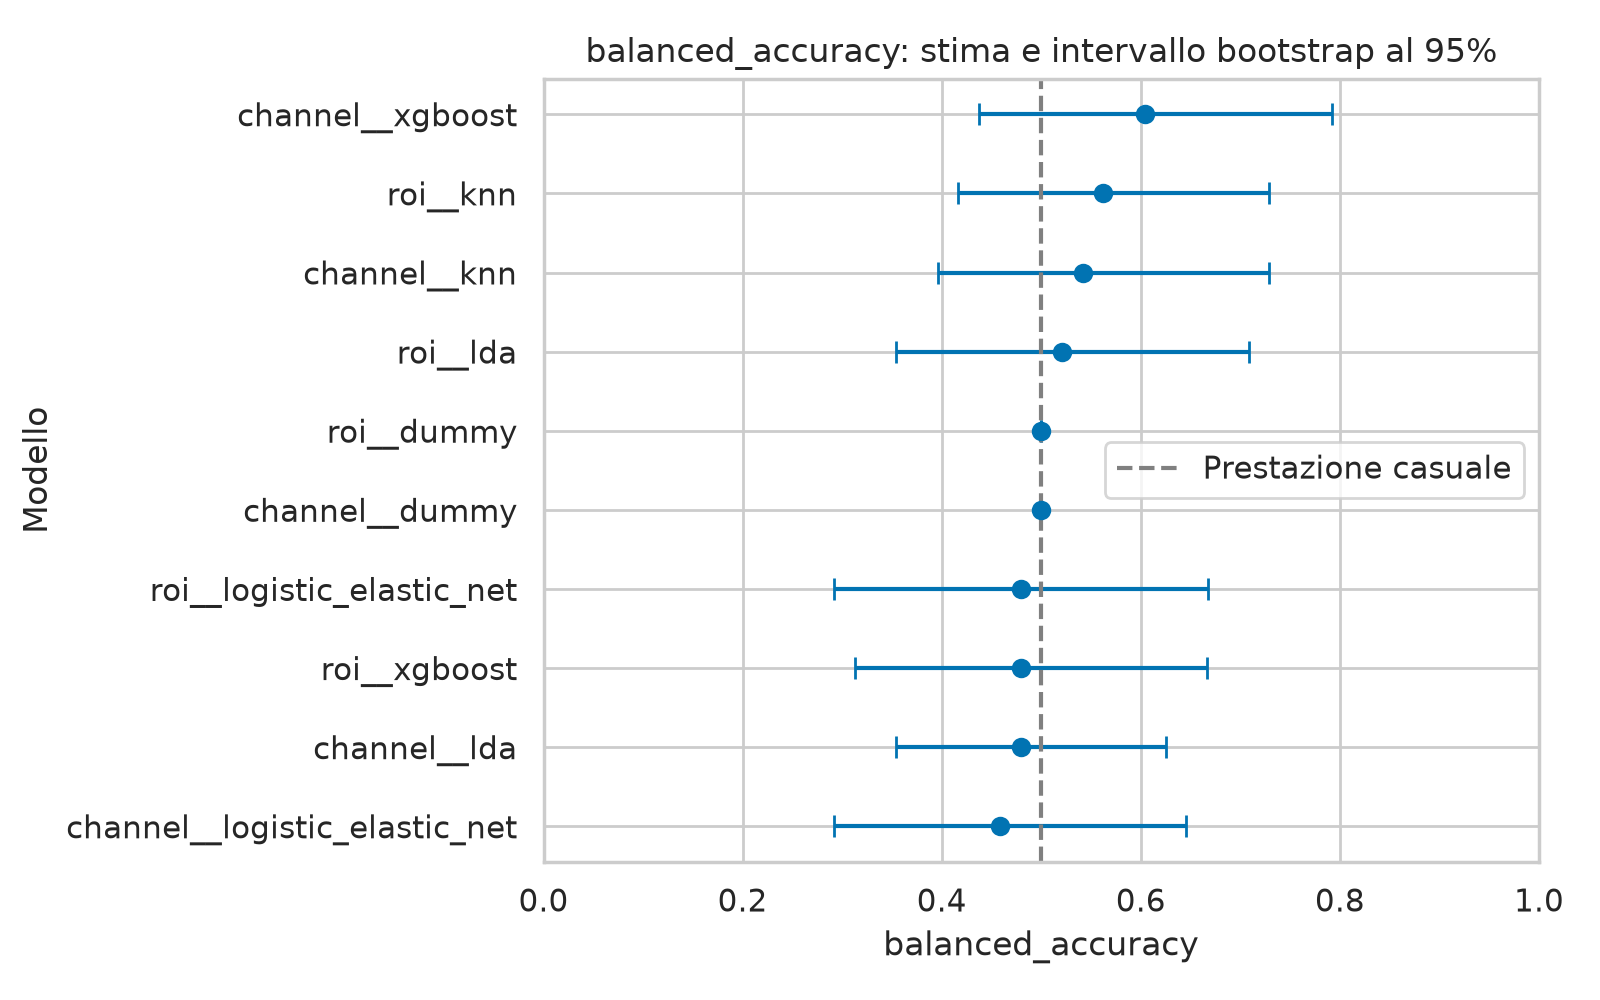

subject_probabilities.png


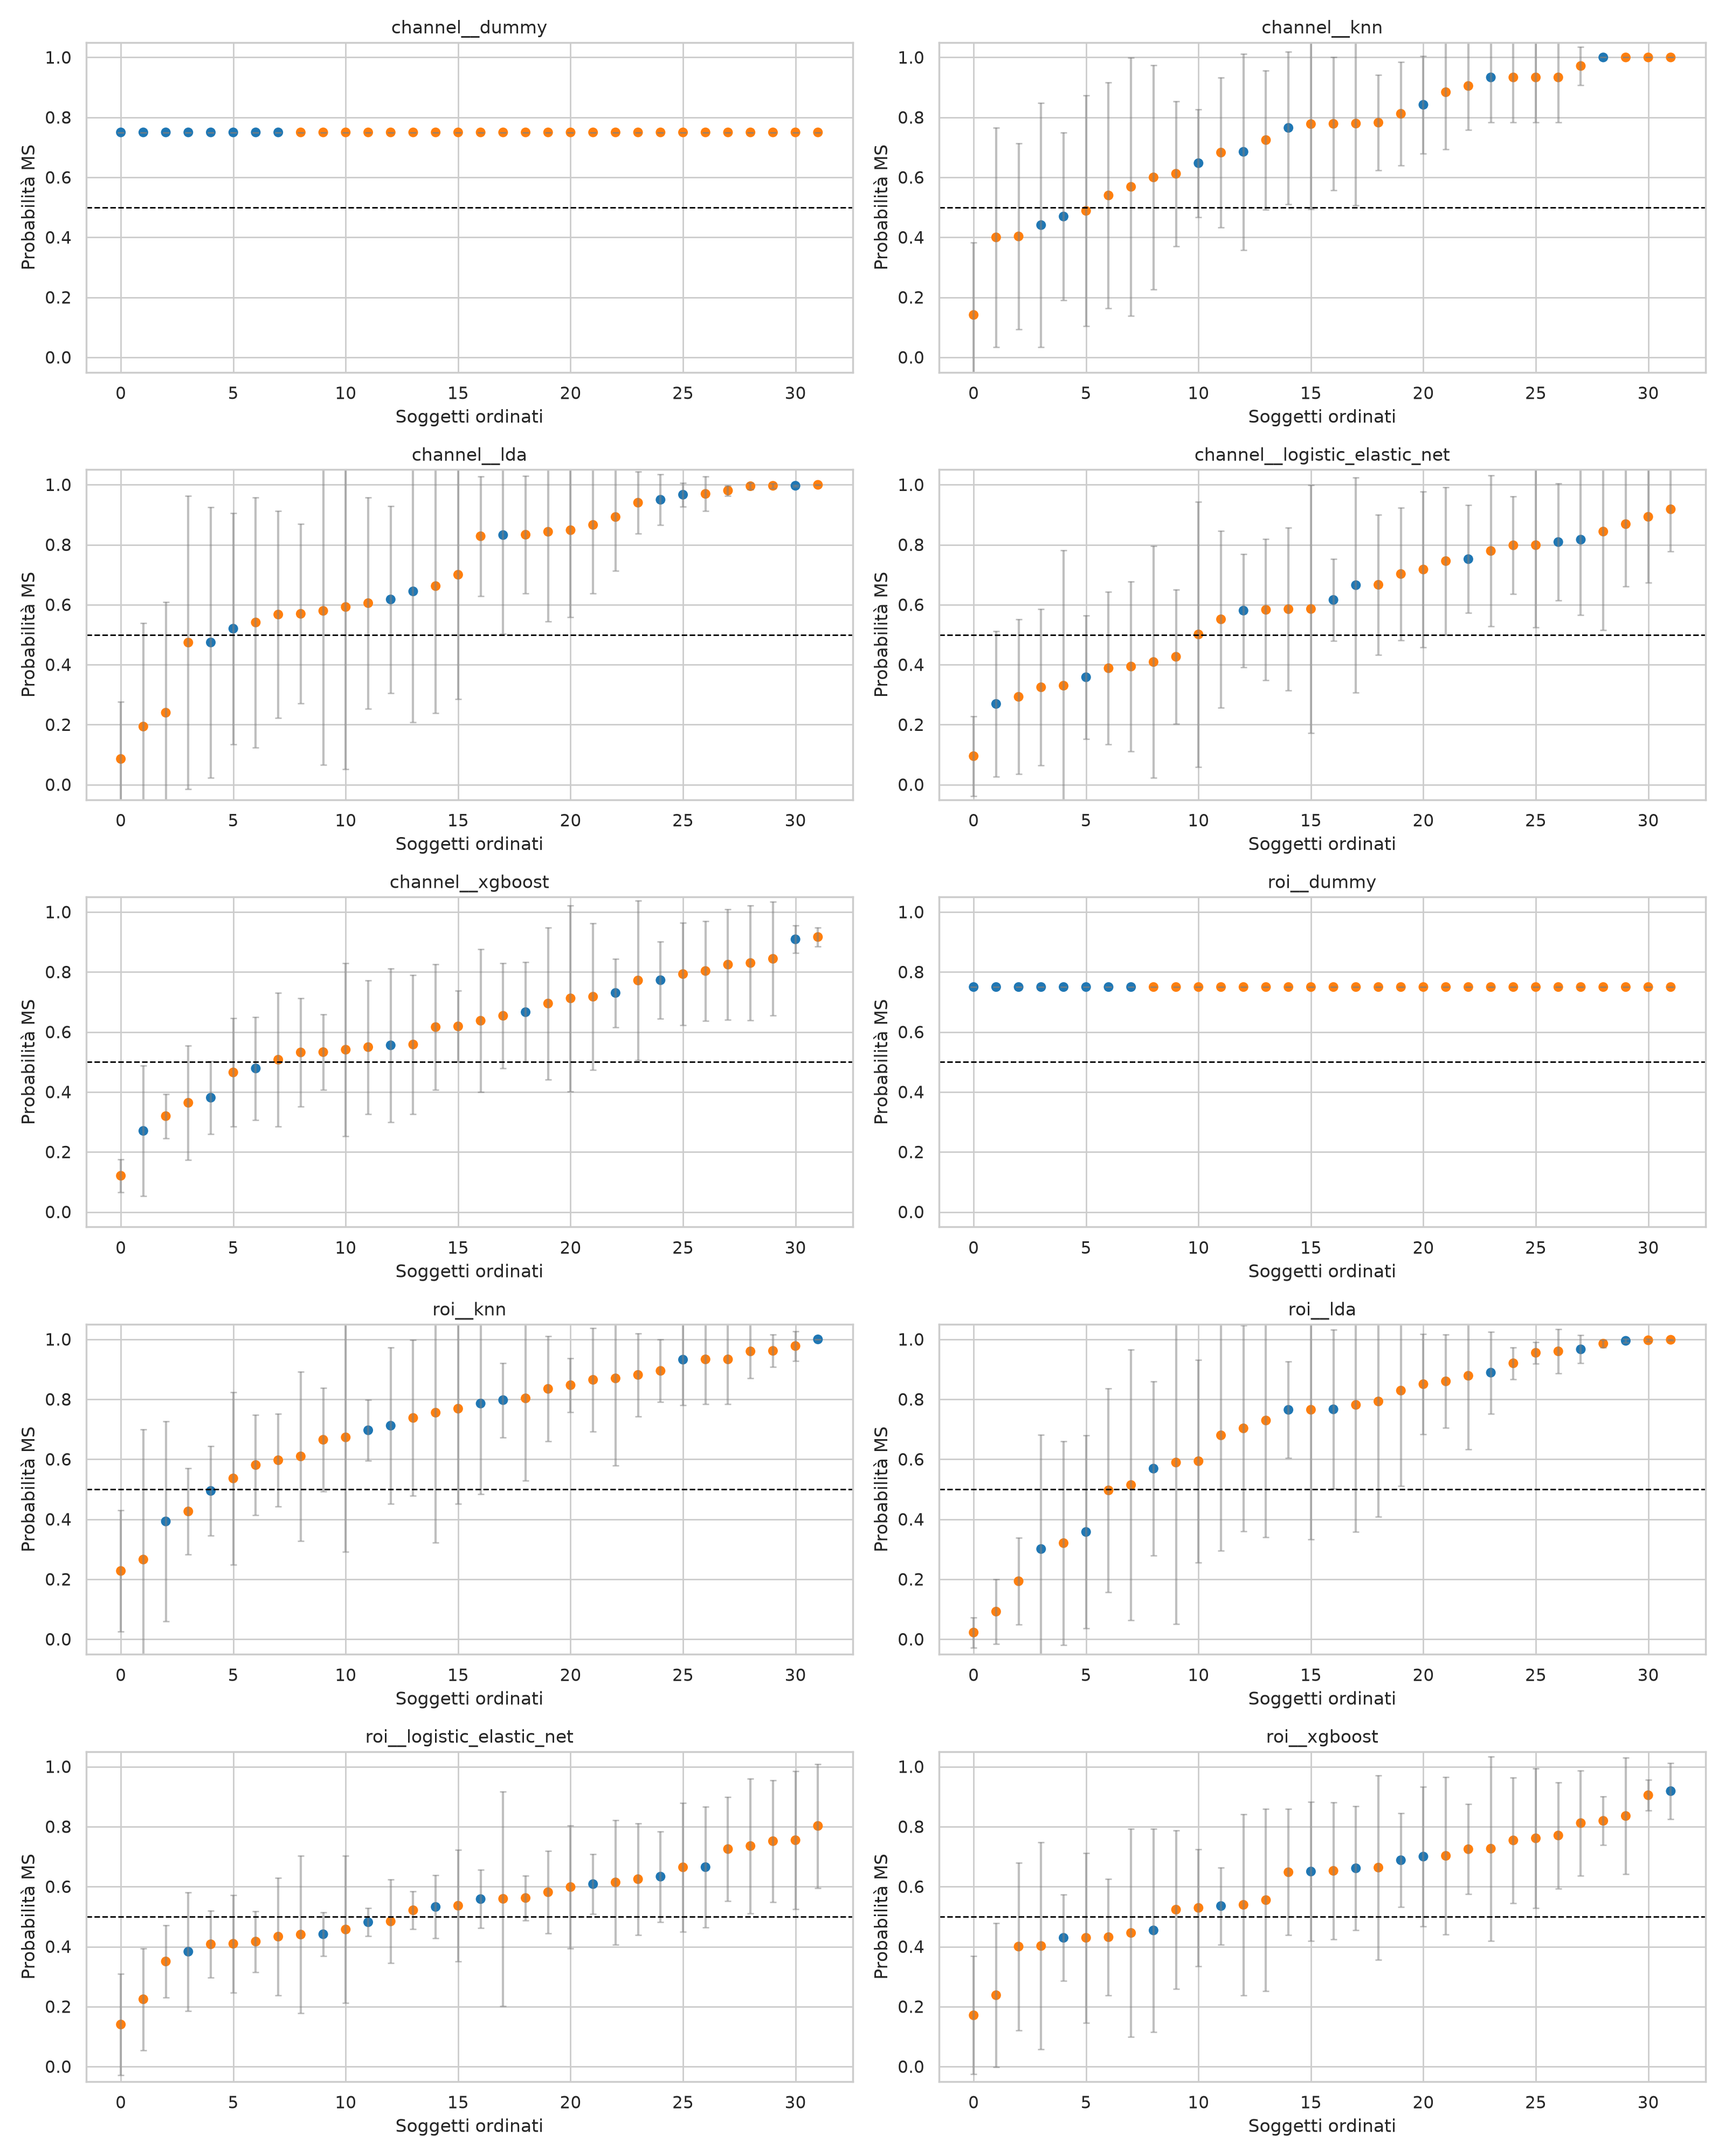

In [ ]:
figure_names = [
    "oof_roc_curves.png",
    "oof_precision_recall_curves.png",
    "confusion_matrices.png",
    "fold_metric_distributions.png",
    "bootstrap_balanced_accuracy.png",
    "subject_probabilities.png",
]
for figure_name in figure_names:
    figure_path = figures_dir/figure_name
    print(figure_name)
    if figure_path.is_file():
        display(Image(filename=str(figure_path)))
    else:
        print("Figura non presente in questo run.")

## Errori per soggetto e stabilità delle feature

Gli errori descrivono il run aggregato e non una valutazione/predizione clinica individuale su soggetto.
La frequenza di selezione indica quanto spesso una feature è stata selezionata nei fit esterni.
Ciò non dimostra causalità né identifica da sola un biomarker.

In [5]:
error_counts = (
    subject_errors.groupby(["model", "error_type"]).size()
    .unstack(fill_value=0)
)
display(error_counts)

real_model_features = feature_stability.loc[
    ~feature_stability["model"].str.endswith("__dummy")
].copy()
top_stable_features = (
    real_model_features.sort_values(
        ["model", "selection_frequency", "mean_absolute_importance"],
        ascending=[True, False, False],
        na_position="last",
    )
    .groupby("model", sort=False)
    .head(3)
    [["model", "feature", "selection_frequency", "mean_absolute_importance"]]
)
display(top_stable_features.reset_index(drop=True).round(3))

error_type,correct,false_negative_ms,false_positive_hc
model,,,
channel__dummy,24,0,8
channel__knn,22,4,6
channel__lda,21,4,7
channel__logistic_elastic_net,18,8,6
channel__random_forest,17,9,6
channel__svm,23,1,8
channel__xgboost,23,4,5
roi__dummy,24,0,8
roi__knn,23,3,6


,model,feature,selection_frequency,mean_absolute_importance
0,channel__knn,psd__relative_power__gamma__channel__F4__std__CE,0.60,NaN
1,channel__knn,psd__relative_power__gamma__channel__F4__max__CE,0.50,NaN
2,channel__knn,psd__relative_power__gamma__channel__F4__iqr__CE,0.45,NaN
3,channel__lda,psd__relative_power__gamma__channel__F4__std__CE,0.55,1.267
4,channel__lda,psd__relative_power__gamma__channel__F4__max__CE,0.50,1.103
5,channel__lda,psd__relative_power__gamma__channel__Fp1__q75__CE,0.50,0.427
6,channel__logistic_elastic_net,psd__relative_power__gamma__channel__F4__std__CE,0.50,0.814
7,channel__logistic_elastic_net,psd__relative_power__gamma__channel__Fp1__q75__CE,0.50,0.264
8,channel__logistic_elastic_net,psd__relative_power__gamma__channel__F4__iqr__CE,0.45,0.908
9,channel__random_forest,psd__relative_power__gamma__channel__F4__iqr__CE,0.90,0.068
